In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch
import matplotlib.pyplot as plt

from src.problems.schrodinger import build_eq_params, sanity_check
from src.utils.logger import Logging
from src.nn.ClassicalSolver2 import ClassicalSolver2
from src.trainer.schrodinger_train import train
from src.problems.schrodinger.problem import build_problem

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = "float64"

print("device:", device, "| dtype:", dtype)


device: cpu | dtype: float64


In [3]:
eq_params = build_eq_params(
    "ho",
    L=6.0,      # dominio suficientemente grande para que la gaussiana decaiga
    T=0.2,
    mass=1.0,
    hbar=1.0,
    omega=1.0,
    n_level=0,  # ground state para empezar
)

print("eq_params:", eq_params)
print("sanity:", sanity_check(eq_params, device=device))


eq_params: {'example': 'ho', 'L': 6.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 0, 'x_min': -6.0, 'x_max': 6.0, 'omega': 1.0, 'V0': 50.0, 'barrier_width': 1.2, 'x_center': 3.0, 'num_grid': 400}
sanity: {'V_min': 0.00045453397641474763, 'V_max': 18.0, 'psi0_norm': 0.28795254238618323, 'psiT_norm': 0.28795254238618323}


In [4]:
args = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,
    "epochs": 2500,
    "lr": 1e-3,
    "batch_size": 64,
    "classic_network": [2, 64, 64, 64, 2],
    "print_every": 100,

    # HO: NO hard BC (dominio truncado)
    "hard_bc": False,

    # pesos anti-solución-trivial
    "w_pde": 1.0,
    "w_bc":  1.0,     # BC suave en x=±L
    "w_ic":  300.0,   # ancla fuerte IC
    "w_norm": 1.0,    # normalización en t=0

    # curriculum
    "warmup_epochs": 400,
    "ic_grid": True,
    "N_norm": 600,
    "N_val": 600,
}

logger = Logging("./results/models/checkpoints/smoke_schrodinger", "ho_Classical")
model = ClassicalSolver2(args, logger, device=torch.device(device))
model.args = args

# dtype coherente con el trainer
model = model.double() if "64" in dtype else model.float()
model = model.to(torch.device(device))

# chequeo de forward (dtype del modelo desde un parámetro)
param_dtype = next(model.parameters()).dtype

t_test = torch.rand(8, 1, device=device, dtype=param_dtype) * eq_params["T"]
x_test = (
    torch.rand(8, 1, device=device, dtype=param_dtype)
    * (eq_params["x_max"] - eq_params["x_min"])
    + eq_params["x_min"]
)

y = model(torch.cat([t_test, x_test], dim=1))
print("forward ok ->", y.shape, y.dtype, y.device)


INFO:src.utils.logger:checkpoint path: self.log_path='./results/models/checkpoints/smoke_schrodinger\\2025-12-21_15-13-27-243320_ho_Classical'


forward ok -> torch.Size([8, 2]) torch.float64 cpu


In [6]:
# HO suele necesitar más puntos internos que box
train(model, N_f=256, N_b=64, N_0=128)


INFO:src.utils.logger:It: 1, Loss: 8.017e-02, Loss_res: 9.994e-03,  Loss_bcs: 6.284e-05, Loss_ut_ics: 2.669e-04, Loss_norm: 1.586e-05, w_pde: 2.50e-03, L^2_error: 1.406e+00, lr: 1.000e-03, Time: 3.86e-02
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-21_15-13-27-243320_ho_Classical\model.pth
INFO:src.utils.logger:Model weights saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-21_15-13-27-243320_ho_Classical\model_weights.pth
INFO:src.utils.logger:It: 100, Loss: 4.877e-02, Loss_res: 7.050e-03,  Loss_bcs: 1.954e-05, Loss_ut_ics: 1.566e-04, Loss_norm: 1.148e-05, w_pde: 2.50e-01, L^2_error: 6.010e-02, lr: 1.000e-03, Time: 2.72e+00
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-21_15-13-27-243320_ho_Classical\model.pth
INFO:src.utils.logger:Model weights saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-21_15-13-27-243320_ho_Classical\model_weights.pth
INFO:src.u

L2_rel(T): 0.01030056927932856


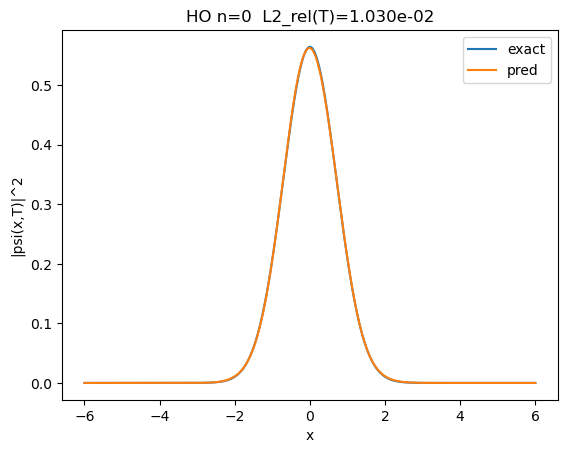

In [7]:
pb = build_problem(eq_params, device=torch.device(device), dtype=torch.float64 if "64" in dtype else torch.float32)

x = torch.linspace(pb["x_min"], pb["x_max"], 800, device=device, dtype=pb["dtype"]).reshape(-1, 1)
t = torch.full_like(x, pb["T"])

with torch.no_grad():
    pred = model(torch.cat([t, x], dim=1))
    pr, pi = pred[:, 0:1], pred[:, 1:2]

    er, ei, _ = pb["exact"](pb["n_level"], t, x)

    l2_abs = torch.sqrt(torch.mean((pr-er)**2 + (pi-ei)**2))
    ref = torch.sqrt(torch.mean(er**2 + ei**2)) + 1e-12
    l2_rel = (l2_abs/ref).item()

print("L2_rel(T):", l2_rel)

prob_pred  = (pr**2 + pi**2).detach().cpu().numpy().flatten()
prob_exact = (er**2 + ei**2).detach().cpu().numpy().flatten()
x_cpu      = x.detach().cpu().numpy().flatten()

plt.figure()
plt.plot(x_cpu, prob_exact, label="exact")
plt.plot(x_cpu, prob_pred,  label="pred")
plt.legend()
plt.xlabel("x")
plt.ylabel("|psi(x,T)|^2")
plt.title(f"HO n={eq_params['n_level']}  L2_rel(T)={l2_rel:.3e}")
plt.show()


In [8]:
import torch

pb = build_problem(eq_params, device=torch.device(device), dtype=torch.float64)
ts = torch.linspace(0.0, eq_params["T"], 30, device=device, dtype=pb["dtype"]).reshape(-1,1)

x_left  = torch.full_like(ts, eq_params["x_min"])
x_right = torch.full_like(ts, eq_params["x_max"])

with torch.no_grad():
    psiL = model(torch.cat([ts, x_left],  dim=1))
    psiR = model(torch.cat([ts, x_right], dim=1))

bcL = torch.sqrt(psiL[:,0]**2 + psiL[:,1]**2).max().item()
bcR = torch.sqrt(psiR[:,0]**2 + psiR[:,1]**2).max().item()

print("max |psi(t,x_min)|:", bcL)
print("max |psi(t,x_max)|:", bcR)

max |psi(t,x_min)|: 0.0005364189451125231
max |psi(t,x_max)|: 0.0031470751715194636


In [9]:
import torch

def count_params(model):
    total = 0
    trainable = 0
    by_block = {}  # desglose por prefijo: preprocessor / quantum_layer / postprocessor / hidden / etc.

    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n

        block = name.split(".")[0]  # primer prefijo (preprocessor, quantum_layer, postprocessor, etc.)
        by_block.setdefault(block, {"total": 0, "trainable": 0})
        by_block[block]["total"] += n
        if p.requires_grad:
            by_block[block]["trainable"] += n

    return total, trainable, by_block


total, trainable, by_block = count_params(model)

print(f"Total parámetros (incluye no-entrenables): {total:,}")
print(f"Parámetros ENTRENABLES (clásicos + cuánticos): {trainable:,}\n")

print("Desglose por bloque (trainables / total):")
for k, v in sorted(by_block.items(), key=lambda kv: -kv[1]["trainable"]):
    print(f"  - {k:15s}: {v['trainable']:,} / {v['total']:,}")

# si quieres además listar SOLO los tensores entrenables:
print("\nListado de parámetros entrenables:")
for name, p in model.named_parameters():
    if p.requires_grad:
        print(f"  {name:40s} {tuple(p.shape)}  numel={p.numel():,}  dtype={p.dtype}")


Total parámetros (incluye no-entrenables): 12,802
Parámetros ENTRENABLES (clásicos + cuánticos): 12,802

Desglose por bloque (trainables / total):
  - preprocessor   : 4,352 / 4,352
  - postprocessor  : 4,290 / 4,290
  - hidden         : 4,160 / 4,160

Listado de parámetros entrenables:
  preprocessor.0.weight                    (64, 2)  numel=128  dtype=torch.float64
  preprocessor.0.bias                      (64,)  numel=64  dtype=torch.float64
  preprocessor.2.weight                    (64, 64)  numel=4,096  dtype=torch.float64
  preprocessor.2.bias                      (64,)  numel=64  dtype=torch.float64
  hidden.0.weight                          (64, 64)  numel=4,096  dtype=torch.float64
  hidden.0.bias                            (64,)  numel=64  dtype=torch.float64
  postprocessor.0.weight                   (64, 64)  numel=4,096  dtype=torch.float64
  postprocessor.0.bias                     (64,)  numel=64  dtype=torch.float64
  postprocessor.2.weight                   (2, 64) 

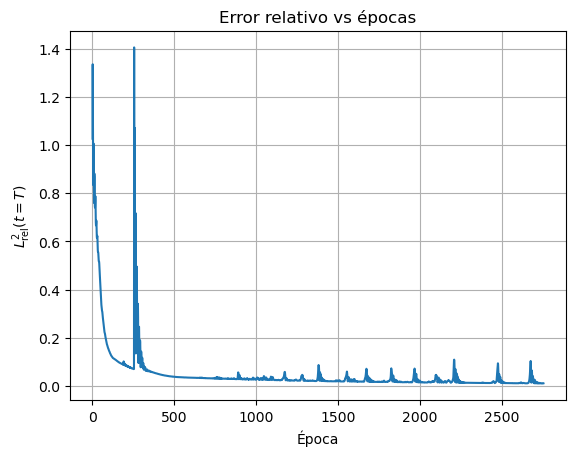

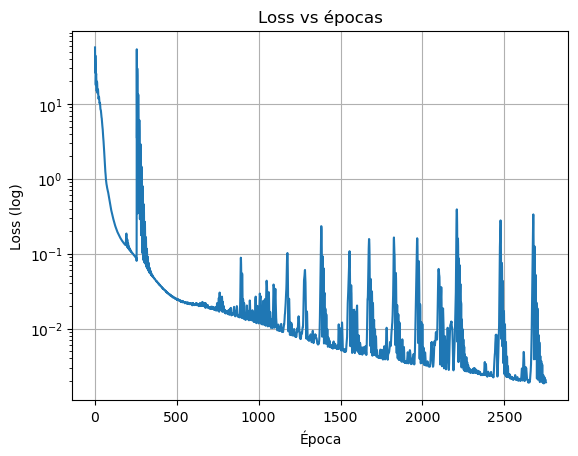

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def get_history(model):
    # intentos comunes (por si el nombre cambia)
    l2_keys = ["l2_rel_history", "l2_history", "l2_error_history"]
    loss_keys = ["loss_history", "losses", "train_loss_history"]

    l2 = None
    for k in l2_keys:
        if hasattr(model, k) and len(getattr(model, k)) > 0:
            l2 = np.array(getattr(model, k), dtype=float)
            break

    loss = None
    for k in loss_keys:
        if hasattr(model, k) and len(getattr(model, k)) > 0:
            loss = np.array(getattr(model, k), dtype=float)
            break

    return loss, l2


loss, l2 = get_history(model)

if loss is None:
    raise AttributeError("No encontré historial de pérdida en el modelo (esperaba model.loss_history).")

if l2 is None:
    raise AttributeError("No encontré historial de error L2 en el modelo (esperaba model.l2_rel_history).")

epochs_loss = np.arange(1, len(loss) + 1)
epochs_l2   = np.arange(1, len(l2) + 1)

plt.figure()
plt.plot(epochs_l2, l2)
plt.xlabel("Época")
plt.ylabel(r"$L^2_{\mathrm{rel}}(t=T)$")
plt.title("Error relativo vs épocas")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs_loss, loss)
plt.yscale("log")
plt.xlabel("Época")
plt.ylabel("Loss (log)")
plt.title("Loss vs épocas")
plt.grid(True)
plt.show()


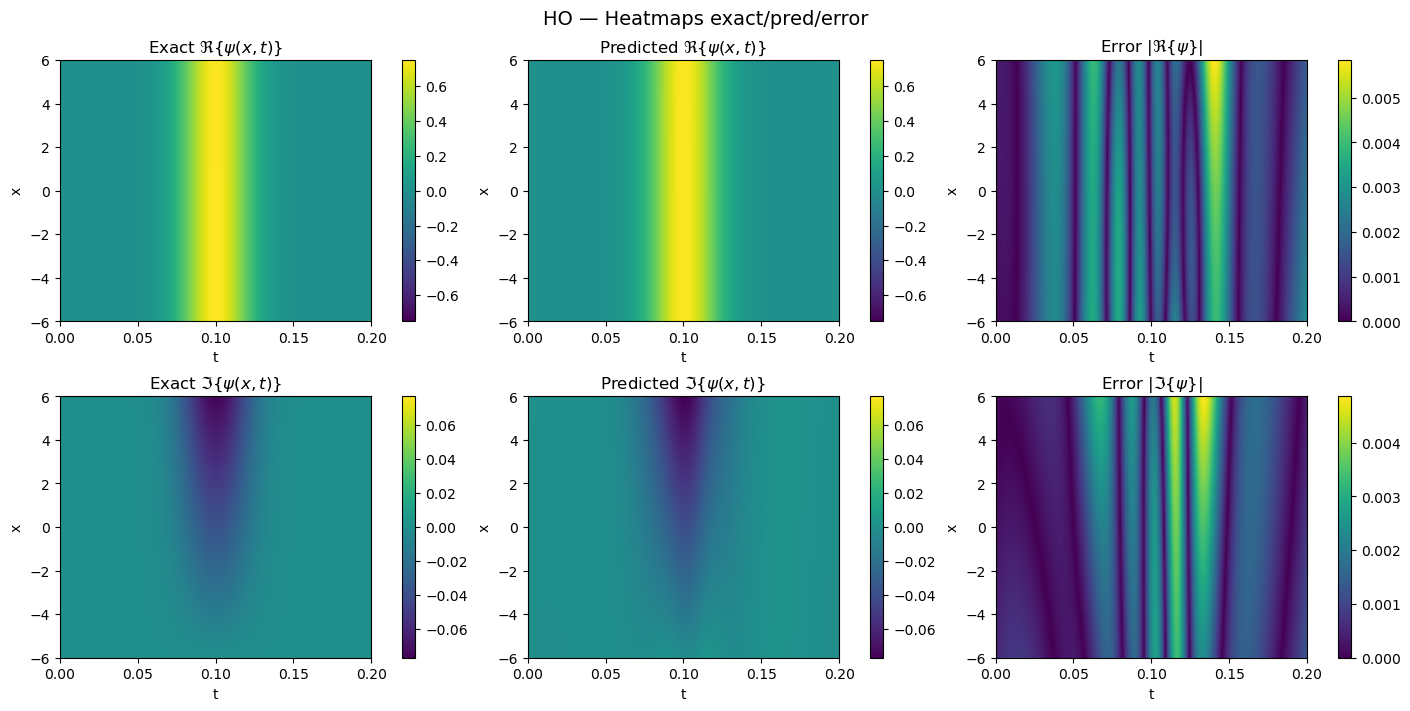

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Necesario: build_problem para exacta y dominio
from src.problems.schrodinger.problem import build_problem

@torch.no_grad()
def eval_model_in_chunks(model, tx, chunk=512):
    """
    Evalúa model(tx) en trozos para no reventar memoria y para no hacer una sola llamada gigante (útil en DV).
    tx: (N,2)
    """
    model.eval()
    outs = []
    N = tx.shape[0]
    for i in range(0, N, chunk):
        outs.append(model(tx[i:i+chunk]))
    return torch.cat(outs, dim=0)

def plot_heatmaps_exact_pred_error(model, eq_params, Nt=120, Nx=220, chunk=512):
    device = next(model.parameters()).device
    dtype  = next(model.parameters()).dtype

    problem = build_problem(eq_params, device=device, dtype=dtype)
    T = float(problem["T"])
    x_min = float(problem["x_min"])
    x_max = float(problem["x_max"])
    n_level = int(problem["n_level"])

    # mallas
    t = torch.linspace(0.0, T, Nt, device=device, dtype=dtype)
    x = torch.linspace(x_min, x_max, Nx, device=device, dtype=dtype)
    TT, XX = torch.meshgrid(t, x, indexing="ij")  # (Nt,Nx)

    t_flat = TT.reshape(-1, 1)
    x_flat = XX.reshape(-1, 1)
    tx = torch.cat([t_flat, x_flat], dim=1)

    # exacta
    psi_r_ex, psi_i_ex, _ = problem["exact"](n_level, t_flat, x_flat)

    # predicción
    psi_pred = eval_model_in_chunks(model, tx, chunk=chunk)
    psi_r_pr = psi_pred[:, 0:1]
    psi_i_pr = psi_pred[:, 1:2]

    # reshape a (Nt,Nx)
    Re_ex = psi_r_ex.reshape(Nt, Nx).detach().cpu().numpy()
    Im_ex = psi_i_ex.reshape(Nt, Nx).detach().cpu().numpy()
    Re_pr = psi_r_pr.reshape(Nt, Nx).detach().cpu().numpy()
    Im_pr = psi_i_pr.reshape(Nt, Nx).detach().cpu().numpy()

    Re_er = np.abs(Re_pr - Re_ex)
    Im_er = np.abs(Im_pr - Im_ex)

    # escalas razonables (simétricas para Re/Im; positivas para error)
    re_max = max(np.max(np.abs(Re_ex)), np.max(np.abs(Re_pr))) + 1e-12
    im_max = max(np.max(np.abs(Im_ex)), np.max(np.abs(Im_pr))) + 1e-12
    re_e_max = np.max(Re_er) + 1e-12
    im_e_max = np.max(Im_er) + 1e-12

    extent = [0.0, T, x_min, x_max]  # x-axis=t, y-axis=x

    fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)

    # --- Re row ---
    im0 = axes[0,0].imshow(Re_ex, origin="lower", aspect="auto", extent=extent, vmin=-re_max, vmax=re_max)
    axes[0,0].set_title(r"Exact $\Re\{\psi(x,t)\}$")
    plt.colorbar(im0, ax=axes[0,0], fraction=0.046)

    im1 = axes[0,1].imshow(Re_pr, origin="lower", aspect="auto", extent=extent, vmin=-re_max, vmax=re_max)
    axes[0,1].set_title(r"Predicted $\Re\{\psi(x,t)\}$")
    plt.colorbar(im1, ax=axes[0,1], fraction=0.046)

    im2 = axes[0,2].imshow(Re_er, origin="lower", aspect="auto", extent=extent, vmin=0.0, vmax=re_e_max)
    axes[0,2].set_title(r"Error $|\Re\{\psi\}|$")
    plt.colorbar(im2, ax=axes[0,2], fraction=0.046)

    # --- Im row ---
    im3 = axes[1,0].imshow(Im_ex, origin="lower", aspect="auto", extent=extent, vmin=-im_max, vmax=im_max)
    axes[1,0].set_title(r"Exact $\Im\{\psi(x,t)\}$")
    plt.colorbar(im3, ax=axes[1,0], fraction=0.046)

    im4 = axes[1,1].imshow(Im_pr, origin="lower", aspect="auto", extent=extent, vmin=-im_max, vmax=im_max)
    axes[1,1].set_title(r"Predicted $\Im\{\psi(x,t)\}$")
    plt.colorbar(im4, ax=axes[1,1], fraction=0.046)

    im5 = axes[1,2].imshow(Im_er, origin="lower", aspect="auto", extent=extent, vmin=0.0, vmax=im_e_max)
    axes[1,2].set_title(r"Error $|\Im\{\psi\}|$")
    plt.colorbar(im5, ax=axes[1,2], fraction=0.046)

    for ax in axes.flat:
        ax.set_xlabel("t")
        ax.set_ylabel("x")

    ex = str(eq_params.get("example", "schrodinger")).upper()
    fig.suptitle(f"{ex} — Heatmaps exact/pred/error", fontsize=14)
    plt.show()

# ---- úsalo así ----
plot_heatmaps_exact_pred_error(model, eq_params, Nt=120, Nx=220, chunk=512)
